# AlgoPerf Scoring: Tables & Performance Profiles

This notebook runs the AlgoPerf scoring pipeline to generate:
- **Submission summary tables** (time to target per workload)
- **Performance profiles** (fraction of workloads solved vs. tau ratio)
- **Leaderboard scores** (area under performance profile)

**Input format** — your submission data must follow this directory structure:
```
submission_directory/
  <submission_name>/
    <study_name>/
      <workload_name>/
        <trial_name>/
          eval_measurements.csv
```

## 1. Install & Import

In [1]:
import os
import pickle
import operator

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from tabulate import tabulate

from scoring import performance_profile, scoring_utils

## 2. Mount Google Drive (optional)

Skip this cell if you are uploading data directly or using a different source.

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

## 3. Configuration

Set the paths and flags below before running the rest of the notebook.

In [3]:
# ── Required ──────────────────────────────────────────────────────────────────
# Path to the directory that contains one sub-folder per submission.
SUBMISSION_DIRECTORY = '/home/kasimbeg/submissions_algorithms/logs/self_tuning'

# Where to write output CSVs and plots.
OUTPUT_DIR = '/home/kasimbeg/submissions_algorithms/scoring_artifacts'

# ── Submission filters (leave empty strings to include/exclude nothing) ───────
# Comma-separated names to include (empty = include all).
INCLUDE_SUBMISSIONS = ''
# Comma-separated names to exclude.
EXCLUDE_SUBMISSIONS = 'muon_torch_jax_hps,muon_torch_jax_hps_achandr,muon_torch_jax_hps_lr_fix,muon_torch_replicated_jax_hps,muon_torch_replicated_torch_hps'

# ── Scoring flags ─────────────────────────────────────────────────────────────
# Set True to enforce the competition's strict trial/study count rules.
STRICT = False
# Set True when scoring the self-tuning ruleset.
SELF_TUNING_RULESET = True
# Set True to compute and plot performance profiles after building summaries.
COMPUTE_PERFORMANCE_PROFILES = True

# ── Performance profile parameters ────────────────────────────────────────────
MIN_TAU = 1.0
MAX_TAU = 4.0   # set None to auto-detect from data
NUM_POINTS = 100
SCALE = 'linear'  # 'linear' or 'log'

# ── Caching (optional) ────────────────────────────────────────────────────────
# Save the parsed results dict so you can reload it later without re-parsing.
SAVE_RESULTS_TO = None   # e.g. 'results.pkl'
# Load a previously saved results dict instead of re-parsing.
LOAD_RESULTS_FROM = None  # e.g. 'results.pkl'

os.makedirs(OUTPUT_DIR, exist_ok=True)

## 3b. Submission Display-Name Map
Edit the right-hand side to control how names appear in tables and plots.\nAny submission not listed here will be shown with its raw folder name.

In [4]:
# Maps raw folder names → display names used in tables, plots, and LaTeX output.
# Add or edit entries freely; unlisted names fall back to their raw folder name.
SUBMISSION_NAME_MAP = {
    'ademamix':                        'AdEMAMix',
    'cautious_nadamw':                 'Cautious NAdamW',
    'lion':                            'Lion',
    'muon':                            'Muon (JAX)',
    'muon_torch':                      'Muon (PyTorch)',
    'muon_torch_jax_hps':              'Muon (PyTorch, JAX HPs)',
    'muon_torch_jax_hps_achandr':      'Muon (PyTorch, JAX HPs, achandr)',
    'muon_torch_jax_hps_lr_fix':       'Muon (PyTorch, JAX HPs, LR Fix)',
    'muon_torch_replicated_jax_hps':   'Muon (Replicated, JAX HPs)',
    'muon_torch_replicated_torch_hps': 'Muon (Replicated, Torch HPs)',
    'nadamw':                          'NAdamW',
    'nadamw_baselinev05':              'NAdamW (Baseline v0.5)',
    'nadamw_resnet':                   'NAdamW (ResNet)',
    'schedule_free_adamw':             'Schedule-Free AdamW',
    'schedule_free_adamw_jax':         'Schedule-Free AdamW (JAX)',
    'schedule_free_adamw_jax_v2':      'Schedule-Free AdamW (JAX v2)',
    'schedule_free_adamw_v2':          'Schedule-Free AdamW v2',
    'single_worker_diloco':            'DiLoCo (Single Worker)',
    'single_worker_dilocov2':          'DiLoCo v2 (Single Worker)',
}

def pretty(name):
    """Return the display name for a submission, falling back to the raw name."""
    return SUBMISSION_NAME_MAP.get(name, name)

## 4. Helper: Submission Summary

These functions mirror `get_summary_df` and `get_submission_summary` from `score_submissions.py`.

In [5]:
def get_summary_df(workload, workload_df):
    """Build a per-trial summary for one workload."""
    validation_metric, validation_target = (
        scoring_utils.get_workload_metrics_and_targets(workload)
    )
    is_minimized = performance_profile.check_if_minimized(validation_metric)
    target_op = operator.le if is_minimized else operator.ge
    best_op   = min        if is_minimized else max
    idx_op    = np.argmin  if is_minimized else np.argmax

    summary_df = pd.DataFrame()
    summary_df['workload']               = workload_df['workload']
    summary_df['trial']                  = workload_df['trial'].apply(lambda x: x[0])
    summary_df['val target metric name'] = validation_metric
    summary_df['val target metric value']= validation_target
    summary_df['val target reached']     = (
        workload_df[validation_metric]
        .apply(lambda x: target_op(x, validation_target))
        .apply(np.any)
    )
    summary_df['best metric value on val'] = workload_df[validation_metric].apply(
        lambda x: best_op(x)
    )
    workload_df = workload_df.copy()
    workload_df['index best eval on val'] = workload_df[validation_metric].apply(
        lambda x: idx_op(x)
    )
    summary_df['time to best eval on val (s)'] = workload_df.apply(
        lambda x: x['accumulated_submission_time'][x['index best eval on val']],
        axis=1,
    )
    workload_df['val target reached'] = (
        workload_df[validation_metric]
        .apply(lambda x: target_op(x, validation_target))
        .apply(np.any)
    )
    workload_df['index to target on val'] = workload_df.apply(
        lambda x: np.argmax(target_op(x[validation_metric], validation_target))
        if x['val target reached'] else np.nan,
        axis=1,
    )
    summary_df['time to target on val (s)'] = workload_df.apply(
        lambda x: x['accumulated_submission_time'][int(x['index to target on val'])]
        if x['val target reached'] else np.inf,
        axis=1,
    )

    def delta(series):
        return series.apply(lambda x: np.diff(x, prepend=0))

    accumulated_time_intervals = delta(workload_df['accumulated_submission_time'])
    step_intervals             = delta(workload_df['global_step'])
    with np.errstate(divide='ignore', invalid='ignore'):
        all_ratios = np.concatenate(
            (accumulated_time_intervals / step_intervals).values
        )
    summary_df['step_time (s)'] = np.nanmedian(all_ratios)
    summary_df['step_hint']     = scoring_utils.get_workload_stephint(workload)
    return summary_df


def get_submission_summary(df):
    """Build and display a summary table for all workloads in a submission."""
    dfs = []
    for workload, group in df.groupby('workload'):
        print(f'  Workload: {workload}')
        summary_df = get_summary_df(workload, group)
        dfs.append(summary_df)
    return pd.concat(dfs)


def compute_leaderboard_score(df, normalize=True):
    """Compute leaderboard score as the integral of a performance profile."""
    scores = np.trapz(df, x=df.columns)
    if normalize:
        scores /= df.columns.max() - df.columns.min()
    return pd.DataFrame(scores, columns=['score'], index=df.index)

## 4b. Plot Theme

Sets a publication-quality matplotlib style and defines `plot_performance_profiles_styled`.\nWith 19 submissions the plot cycles through 10 colorblind-safe colors × 4 line styles so it stays readable in greyscale and print.

In [6]:
import itertools
import math
import matplotlib as mpl

# ── Colorblind-safe 10-color palette (Paul Tol "bright") ──────────────────────
_COLORS = [
    '#4477AA',  # blue
    '#EE6677',  # red
    '#228833',  # green
    '#CCBB44',  # yellow
    '#66CCEE',  # cyan
    '#AA3377',  # purple
    '#BBBBBB',  # grey
    '#EE7733',  # orange
    '#009988',  # teal
    '#CC3311',  # vermillion
]
_LINE_STYLES = ['-', '--', '-.', ':']

# 10 solid lines, then 9 dashed, etc. — enough for 19 submissions.
_STYLE_CYCLE = list(itertools.islice(
    ((c, ls) for ls in _LINE_STYLES for c in _COLORS),
    40,
))

# ── rcParams: tuned for a two-column tech-report (e.g. NeurIPS / ICML) ────────
mpl.rcParams.update({
    'figure.figsize':        (9, 4.5),
    'figure.dpi':            150,
    'savefig.dpi':           300,
    'savefig.bbox':          'tight',
    'savefig.pad_inches':    0.05,
    'font.family':           'serif',
    'font.serif':            ['Times New Roman', 'DejaVu Serif'],
    'font.size':             11,
    'axes.titlesize':        11,
    'axes.labelsize':        11,
    'xtick.labelsize':       10,
    'ytick.labelsize':       10,
    'legend.fontsize':       8.5,
    'legend.title_fontsize': 9,
    'legend.framealpha':     0.92,
    'legend.edgecolor':      '#cccccc',
    'legend.borderpad':      0.5,
    'legend.labelspacing':   0.35,
    'axes.grid':             True,
    'grid.alpha':            0.3,
    'grid.linestyle':        '--',
    'grid.linewidth':        0.6,
    'axes.spines.top':       False,
    'axes.spines.right':     False,
    'axes.linewidth':        0.8,
    'lines.linewidth':       1.6,
})


def plot_performance_profiles_styled(
    perf_df,
    df_col,
    scale='linear',
    save_dir=None,
    figsize=(9, 4.5),
    title=None,
):
    """
    Publication-quality performance profile plot for a tech report.

    Each submission gets a unique (color, line-style) pair so the figure
    remains legible in greyscale and for colorblind readers.
    The legend is placed below the plot.
    Saves both a vector PDF and a 300-dpi PNG.
    """
    style_iter = iter(_STYLE_CYCLE)

    fig, ax = plt.subplots(figsize=figsize)

    for submission in perf_df.index:
        color, linestyle = next(style_iter)
        ax.plot(
            perf_df.columns,
            perf_df.loc[submission],
            label=submission,
            color=color,
            linestyle=linestyle,
            linewidth=1.6,
            alpha=0.92,
        )

    ax.set_xlabel('Performance ratio τ  (relative to best submission)')
    ax.set_ylabel('Fraction of workloads solved ρ(τ)')
    ax.set_xlim(perf_df.columns.min(), perf_df.columns.max())
    ax.set_ylim(-0.02, 1.05)
    ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1, decimals=0))

    if title:
        ax.set_title(title, pad=8)

    # ── Legend below the axes ──────────────────────────────────────────────────
    n = len(perf_df.index)
    ncol = max(3, math.ceil(n / 4))   # ~4 rows for any submission count
    ax.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.16),
        ncol=ncol,
        borderaxespad=0,
        frameon=True,
        handlelength=2.0,
        handleheight=0.9,
        columnspacing=1.0,
        labelspacing=0.35,
    )

    # Reserve vertical space proportional to the number of legend rows so the
    # legend never overlaps the x-axis label.
    n_rows = math.ceil(n / ncol)
    pts_per_row = mpl.rcParams['legend.fontsize'] * 1.55
    fig_height_pts = figsize[1] * 72
    legend_frac = (n_rows * pts_per_row + 28) / fig_height_pts
    fig.subplots_adjust(
        left=0.07,
        right=0.98,
        top=0.91 if title else 0.97,
        bottom=min(0.10 + legend_frac, 0.55),
    )

    if save_dir:
        base = os.path.join(save_dir, f'performance_profile_by_{df_col}')
        fig.savefig(f'{base}.pdf', format='pdf')
        fig.savefig(f'{base}.png', format='png', dpi=300)
        print(f'Saved → {base}.pdf / .png')

    return fig, ax

## 5. Load & Summarize Submissions

In [7]:
results = {}

_exclude     = {s.strip() for s in EXCLUDE_SUBMISSIONS.split(',')} - {''}
_include_raw = {s.strip() for s in INCLUDE_SUBMISSIONS.split(',')} - {''}

print(f'Excluding ({len(_exclude)}): {sorted(_exclude) or "(none)"}')
print(f'Including ({len(_include_raw)}): {sorted(_include_raw) or "(all)"}')

def _is_included(raw_name):
    if raw_name in _exclude:
        return False
    if _include_raw and raw_name not in _include_raw:
        return False
    return True

if LOAD_RESULTS_FROM:
    load_path = os.path.join(OUTPUT_DIR, LOAD_RESULTS_FROM)
    print(f'\nLoading cached results from {load_path}')
    with open(load_path, 'rb') as f:
        cached = pickle.load(f)
    _pretty_to_raw = {v: k for k, v in SUBMISSION_NAME_MAP.items()}
    for name, df in cached.items():
        raw = _pretty_to_raw.get(name, name)
        if _is_included(raw):
            results[name] = df
            print(f'  ✓ {name}')
        else:
            print(f'  ✗ {name}  ← excluded')
else:
    all_submission_dirs = sorted(os.listdir(SUBMISSION_DIRECTORY))
    print(f'\nFound {len(all_submission_dirs)} folders:')
    for s in all_submission_dirs:
        tag = '✓' if _is_included(s) else '✗  ← excluded'
        print(f'  {tag} {s}')
    print()

    for submission in all_submission_dirs:
        if not _is_included(submission):
            continue
        print(f'\n=== {pretty(submission)} ({submission}) ===')
        experiment_path = os.path.join(SUBMISSION_DIRECTORY, submission)
        df = scoring_utils.get_experiment_df(experiment_path)
        results[pretty(submission)] = df

        summary_df = get_submission_summary(df)
        summary_df.to_csv(os.path.join(OUTPUT_DIR, f'{submission}_summary.csv'))
        display(summary_df)

    if SAVE_RESULTS_TO:
        save_path = os.path.join(OUTPUT_DIR, SAVE_RESULTS_TO)
        with open(save_path, 'wb') as f:
            pickle.dump(results, f)
        print(f'Results cached to {save_path}')

print(f'\nLoaded {len(results)} submission(s): {list(results.keys())}')

Excluding (5): ['muon_torch_jax_hps', 'muon_torch_jax_hps_achandr', 'muon_torch_jax_hps_lr_fix', 'muon_torch_replicated_jax_hps', 'muon_torch_replicated_torch_hps']
Including (0): (all)

Found 19 folders:
  ✓ ademamix
  ✓ cautious_nadamw
  ✓ lion
  ✓ muon
  ✓ muon_torch
  ✗  ← excluded muon_torch_jax_hps
  ✗  ← excluded muon_torch_jax_hps_achandr
  ✗  ← excluded muon_torch_jax_hps_lr_fix
  ✗  ← excluded muon_torch_replicated_jax_hps
  ✗  ← excluded muon_torch_replicated_torch_hps
  ✓ nadamw
  ✓ nadamw_baselinev05
  ✓ nadamw_resnet
  ✓ schedule_free_adamw
  ✓ schedule_free_adamw_jax
  ✓ schedule_free_adamw_jax_v2
  ✓ schedule_free_adamw_v2
  ✓ single_worker_diloco
  ✓ single_worker_dilocov2


=== AdEMAMix (ademamix) ===
['imagenet_resnet_pytorch', 'fastmri_pytorch', 'imagenet_vit_pytorch', 'librispeech_conformer_pytorch', 'ogbg_pytorch', 'librispeech_deepspeech_pytorch', 'wmt_pytorch', 'criteo1tb_pytorch', 'finewebedu_lm_pytorch']
['imagenet_resnet_pytorch', 'fastmri_pytorch', 'imagenet

2026-07-08 17:40:55.479604: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783532455.503891  709114 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783532455.511874  709114 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783532455.533675  709114 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783532455.533708  709114 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783532455.533710  709114 computation_placer.cc:177] computation placer alr

  Workload: fastmri_pytorch
  Workload: finewebedu_lm_pytorch


I0000 00:00:1783532460.611908  709114 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38367 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:00:04.0, compute capability: 8.0
I0000 00:00:1783532460.613816  709114 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 38367 MB memory:  -> device: 1, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:00:05.0, compute capability: 8.0
I0000 00:00:1783532460.616117  709114 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 38367 MB memory:  -> device: 2, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:00:06.0, compute capability: 8.0
I0000 00:00:1783532460.617874  709114 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 38367 MB memory:  -> device: 3, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:00:07.0, compute capability: 8.0


  Workload: imagenet_resnet_pytorch
  Workload: imagenet_vit_pytorch
  Workload: librispeech_conformer_pytorch
  Workload: librispeech_deepspeech_pytorch
  Workload: ogbg_pytorch
  Workload: wmt_pytorch


...


=== DiLoCo (Single Worker) (single_worker_diloco) ===
['imagenet_resnet_jax', 'fastmri_jax', 'wmt_jax', 'ogbg_jax', 'librispeech_conformer_jax', 'librispeech_deepspeech_jax', 'imagenet_vit_jax', 'finewebedu_lm_jax', 'criteo1tb_jax']
['imagenet_resnet_jax', 'fastmri_jax', 'wmt_jax', 'ogbg_jax', 'librispeech_conformer_jax', 'librispeech_deepspeech_jax', 'imagenet_vit_jax', 'finewebedu_lm_jax', 'criteo1tb_jax']
['imagenet_resnet_jax', 'fastmri_jax', 'wmt_jax', 'ogbg_jax', 'librispeech_conformer_jax', 'librispeech_deepspeech_jax', 'imagenet_vit_jax', 'finewebedu_lm_jax', 'criteo1tb_jax']
  Workload: criteo1tb_jax
  Workload: fastmri_jax
  Workload: finewebedu_lm_jax
  Workload: imagenet_resnet_jax
  Workload: imagenet_vit_jax
  Workload: librispeech_conformer_jax
  Workload: librispeech_deepspeech_jax
  Workload: ogbg_jax
  Workload: wmt_jax


,workload,trial,val target metric name,val target metric value,val target reached,best metric value on val,time to best eval on val (s),time to target on val (s),step_time (s),step_hint
8,criteo1tb_jax,trial_1,validation/loss,0.123735,False,0.124005,12536.648544,inf,2.029254,10666
17,criteo1tb_jax,trial_1,validation/loss,0.123735,False,0.124177,13238.606914,inf,2.029254,10666
25,criteo1tb_jax,trial_1,validation/loss,0.123735,True,0.123679,8951.699251,8.951699e+03,2.029254,10666
1,fastmri_jax,trial_1,validation/ssim,0.723653,True,0.724345,1824.361733,1.824362e+03,1.010139,18094
10,fastmri_jax,trial_1,validation/ssim,0.723653,True,0.724033,2934.323400,2.934323e+03,1.010139,18094
7,finewebedu_lm_jax,trial_1,validation/ppl,22.432000,True,21.299927,28315.804241,2.831580e+04,0.461929,72000
16,finewebedu_lm_jax,trial_1,validation/ppl,22.432000,True,21.323351,28314.819189,2.831482e+04,0.461929,72000
24,finewebedu_lm_jax,trial_1,validation/ppl,22.432000,True,21.302589,28313.505345,2.831351e+04,0.461929,72000
0,imagenet_resnet_jax,trial_1,validation/accuracy,0.774310,False,0.758640,59924.762427,inf,0.254795,195999
9,imagenet_resnet_jax,trial_1,validation/accuracy,0.774310,False,0.760840,73905.253106,inf,0.254795,195999



=== DiLoCo v2 (Single Worker) (single_worker_dilocov2) ===
['imagenet_resnet_jax', 'fastmri_jax', 'wmt_jax', 'ogbg_jax', 'librispeech_conformer_jax', 'librispeech_deepspeech_jax', 'imagenet_vit_jax', 'finewebedu_lm_jax', 'criteo1tb_jax']
['imagenet_resnet_jax', 'fastmri_jax', 'wmt_jax', 'ogbg_jax', 'librispeech_conformer_jax', 'librispeech_deepspeech_jax', 'imagenet_vit_jax', 'finewebedu_lm_jax', 'criteo1tb_jax']
['imagenet_resnet_jax', 'fastmri_jax', 'wmt_jax', 'ogbg_jax', 'librispeech_conformer_jax', 'librispeech_deepspeech_jax', 'imagenet_vit_jax', 'finewebedu_lm_jax', 'criteo1tb_jax']
  Workload: criteo1tb_jax
  Workload: fastmri_jax
  Workload: finewebedu_lm_jax
  Workload: imagenet_resnet_jax
  Workload: imagenet_vit_jax
  Workload: librispeech_conformer_jax
  Workload: librispeech_deepspeech_jax
  Workload: ogbg_jax
  Workload: wmt_jax


,workload,trial,val target metric name,val target metric value,val target reached,best metric value on val,time to best eval on val (s),time to target on val (s),step_time (s),step_hint
8,criteo1tb_jax,trial_1,validation/loss,0.123735,False,0.124271,13033.471937,inf,1.957256,10666
17,criteo1tb_jax,trial_1,validation/loss,0.123735,False,0.124327,12450.281544,inf,1.957256,10666
25,criteo1tb_jax,trial_1,validation/loss,0.123735,False,0.124366,12143.230377,inf,1.957256,10666
1,fastmri_jax,trial_1,validation/ssim,0.723653,True,0.724679,3013.444574,3.013445e+03,1.213146,18094
10,fastmri_jax,trial_1,validation/ssim,0.723653,True,0.723714,2578.141947,2.578142e+03,1.213146,18094
19,fastmri_jax,trial_1,validation/ssim,0.723653,True,0.723721,2561.646830,2.561647e+03,1.213146,18094
7,finewebedu_lm_jax,trial_1,validation/ppl,22.432000,True,21.837119,28313.973881,2.831397e+04,0.474875,72000
16,finewebedu_lm_jax,trial_1,validation/ppl,22.432000,True,21.668298,28312.441187,2.831244e+04,0.474875,72000
24,finewebedu_lm_jax,trial_1,validation/ppl,22.432000,True,22.063855,28316.034054,2.831603e+04,0.474875,72000
0,imagenet_resnet_jax,trial_1,validation/accuracy,0.774310,False,0.735240,71938.876954,inf,0.494305,195999



Loaded 14 submission(s): ['AdEMAMix', 'Cautious NAdamW', 'Lion', 'Muon (JAX)', 'Muon (PyTorch)', 'NAdamW', 'NAdamW (Baseline v0.5)', 'NAdamW (ResNet)', 'Schedule-Free AdamW', 'Schedule-Free AdamW (JAX)', 'Schedule-Free AdamW (JAX v2)', 'Schedule-Free AdamW v2', 'DiLoCo (Single Worker)', 'DiLoCo v2 (Single Worker)']


## 6. Performance Profiles & Leaderboard Scores

Saved → /home/kasimbeg/submissions_algorithms/scoring_artifacts/performance_profile_by_score.pdf / .png


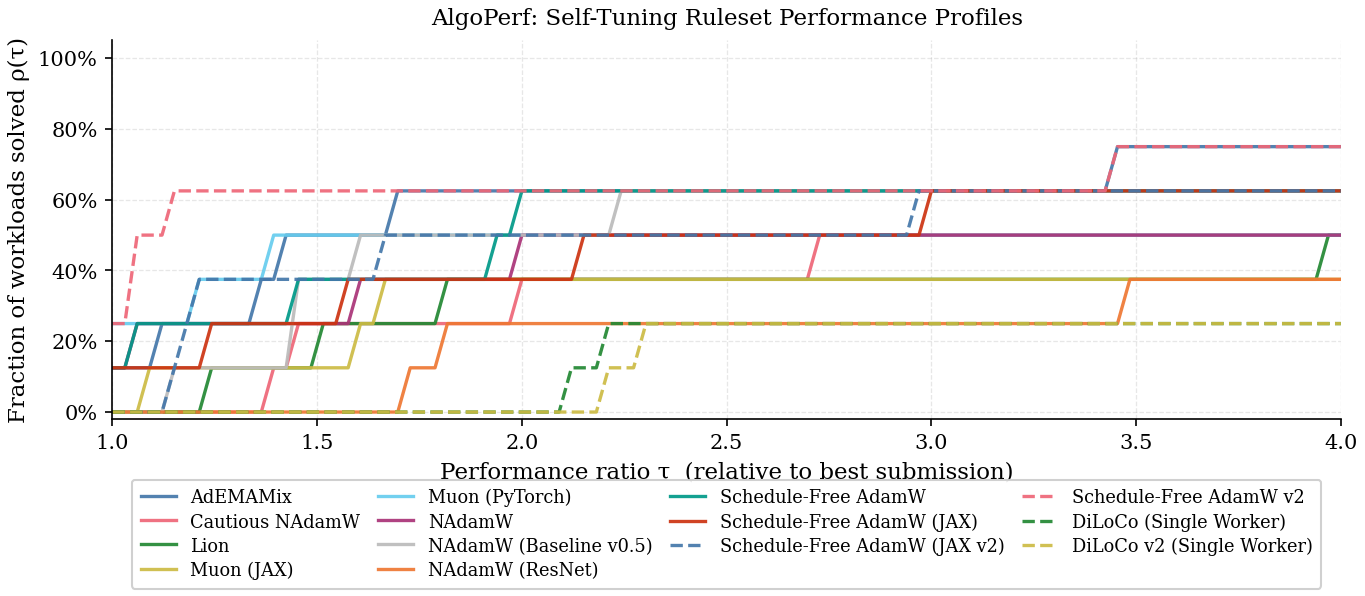


--- Leaderboard Scores ---


/tmp/ipykernel_709114/3734530332.py:74: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  scores = np.trapz(df, x=df.columns)


,score
submission,
Schedule-Free AdamW v2,0.638889
AdEMAMix,0.583965
Schedule-Free AdamW,0.525253
NAdamW (Baseline v0.5),0.506944
Schedule-Free AdamW (JAX v2),0.495581
Muon (PyTorch),0.476010
Schedule-Free AdamW (JAX),0.462121
NAdamW,0.432449
Cautious NAdamW,0.353535


Saved to /home/kasimbeg/submissions_algorithms/scoring_artifacts/scores.csv


In [8]:
if not STRICT:
    print(
        'WARNING: STRICT=False relaxes criteria on held-out workloads, '
        'trial counts, and study counts. Scores may not match official '
        'competition scoring. Set STRICT=True to enforce all rules.'
    )

if COMPUTE_PERFORMANCE_PROFILES:
    performance_profile_df = performance_profile.compute_performance_profiles(
        results,
        time_col='score',
        min_tau=MIN_TAU,
        max_tau=MAX_TAU,
        reference_submission_tag=None,
        num_points=NUM_POINTS,
        scale=SCALE,
        verbosity=0,
        self_tuning_ruleset=SELF_TUNING_RULESET,
        strict=STRICT,
        output_dir=OUTPUT_DIR,
    )

    # Save profile CSV so the Reload section (Section 7) always reflects the
    # current run rather than loading a stale file from a previous run.
    profile_csv = os.path.join(OUTPUT_DIR, 'performance_profile_score.csv')
    performance_profile_df.to_csv(profile_csv)

    # ── Styled plot ────────────────────────────────────────────────────────────
    fig, ax = plot_performance_profiles_styled(
        performance_profile_df,
        'score',
        scale=SCALE,
        save_dir=OUTPUT_DIR,
        title='AlgoPerf: Self-Tuning Ruleset Performance Profiles',
    )
    plt.show()

    # ── Scores table ──────────────────────────────────────────────────────────
    scores = compute_leaderboard_score(performance_profile_df)
    scores_path = os.path.join(OUTPUT_DIR, 'scores.csv')
    scores.to_csv(scores_path)

    print('\n--- Leaderboard Scores ---')
    display(scores.sort_values('score', ascending=False))
    print(f'Saved to {scores_path}')

## 6b. Time-to-Target Table
Shows the median time (seconds) each submission took to reach the validation target on each workload.\n`inf` means the target was not reached within the run.

In [9]:
ttt = pd.read_csv(os.path.join(OUTPUT_DIR, 'time_to_targets.csv'), index_col=0)

# Format: finite values as "Xs", inf as em-dash
def _fmt(v):
    if pd.isna(v) or v == float('inf'):
        return r'\textemdash{}'
    return f'{v:,.0f}s'

ttt_display = ttt.map(_fmt)
ttt_display.index.name = 'Submission'

print('--- Time to Target (seconds) ---')
display(ttt_display)

# ── Workload column → LaTeX macro ─────────────────────────────────────────────
_WL_MACRO = {
    'criteo1tb':              r'\criteo',
    'fastmri':                r'\fastmri',
    'finewebedu_lm':          r'\finewebedu',
    'imagenet_resnet':        r'\resnet',
    'imagenet_vit':           r'\vit',
    'librispeech_conformer':  r'\conformer',
    'librispeech_deepspeech': r'\deepspeech',
    'ogbg':                   r'\ogbg',
    'wmt':                    r'\wmt',
}

workloads  = list(ttt.columns)
col_spec   = 'l' + 'r' * len(workloads)
wl_headers = ' & '.join(_WL_MACRO.get(w, w) for w in workloads)

rows = []
for name, row in ttt_display.iterrows():
    rows.append('      ' + name + ' & ' + ' & '.join(str(v) for v in row) + r' \\')

latex = '\n'.join([
    r'\begin{table}[htbp]',
    r'  \centering',
    r'  \caption{Time to target (seconds). \textemdash{} = target not reached.}',
    r'  \label{tab:time_to_target}',
    r'  \resizebox{\textwidth}{!}{%',
    r'  \begin{tabular}{' + col_spec + '}',
    r'    \toprule',
    r'    Submission & ' + wl_headers + r' \\',
    r'    \midrule',
    *rows,
    r'    \bottomrule',
    r'  \end{tabular}%',
    r'  }',
    r'\end{table}',
])

ttt_latex_path = os.path.join(OUTPUT_DIR, 'time_to_target_table.tex')
with open(ttt_latex_path, 'w') as f:
    f.write(latex)
print(f'\nLaTeX saved → {ttt_latex_path}')


--- Time to Target (seconds) ---


,criteo1tb,fastmri,finewebedu_lm,imagenet_resnet,imagenet_vit,librispeech_conformer,librispeech_deepspeech,ogbg,wmt
Submission,,,,,,,,,
AdEMAMix,"7,839s","1,518s","18,026s",\textemdash{},\textemdash{},"48,895s",\textemdash{},"6,330s","17,400s"
Cautious NAdamW,\textemdash{},"1,608s","25,739s",\textemdash{},\textemdash{},\textemdash{},\textemdash{},"4,993s","14,232s"
Lion,\textemdash{},"1,394s","23,172s",\textemdash{},\textemdash{},\textemdash{},\textemdash{},"7,224s","15,476s"
Muon (JAX),\textemdash{},"1,870s","20,594s",\textemdash{},"77,163s",\textemdash{},\textemdash{},\textemdash{},\textemdash{}
Muon (PyTorch),"7,142s",\textemdash{},"15,472s",\textemdash{},\textemdash{},\textemdash{},\textemdash{},"1,833s","14,215s"
NAdamW,"7,493s","1,801s","25,734s",\textemdash{},"72,016s",\textemdash{},\textemdash{},\textemdash{},\textemdash{}
NAdamW (Baseline v0.5),"8,206s","1,621s","20,590s",\textemdash{},\textemdash{},\textemdash{},\textemdash{},"4,090s","14,866s"
NAdamW (ResNet),\textemdash{},"1,921s","23,163s",\textemdash{},\textemdash{},\textemdash{},\textemdash{},"6,350s",\textemdash{}
Schedule-Free AdamW,"10,338s","1,189s",\textemdash{},\textemdash{},\textemdash{},\textemdash{},"40,463s","3,640s","19,958s"



LaTeX saved → /home/kasimbeg/submissions_algorithms/scoring_artifacts/time_to_target_table.tex


## 7. LaTeX Tables
Generates a ready-to-paste LaTeX table of leaderboard scores, sorted best-first.\
nRun after Section 6.

In [10]:
def scores_to_latex(scores_df, caption='AlgoPerf Self-Tuning Leaderboard', label='tab:scores'):
    """
    Render a leaderboard scores DataFrame as a LaTeX table.
    Submission names come from the DataFrame index (already pretty-named).
    Scores are formatted to 4 decimal places; best score is bolded.
    """
    df = scores_df.sort_values('score', ascending=False).copy()
    df['rank'] = range(1, len(df) + 1)

    best_score = df['score'].iloc[0]

    rows = []
    for rank, (name, row) in enumerate(df.iterrows(), start=1):
        score_str = f'{row["score"]:.4f}'
        if row['score'] == best_score:
            score_str = r'\textbf{' + score_str + '}'
        rows.append(f'    {rank} & {name} & {score_str} \\\\')

    body = '\n'.join(rows)

    latex = (
        r'\begin{table}[h]' + '\n'
        r'  \centering' + '\n'
        r'  \caption{' + caption + '}\n'
        r'  \label{' + label + '}\n'
        r'  \begin{tabular}{rlr}' + '\n'
        r'    \toprule' + '\n'
        r'    Rank & Submission & Score \\' + '\n'
        r'    \midrule' + '\n'
        + body + '\n'
        r'    \bottomrule' + '\n'
        r'  \end{tabular}' + '\n'
        r'\end{table}'
    )
    return latex


latex_table = scores_to_latex(scores)
print(latex_table)

latex_path = os.path.join(OUTPUT_DIR, 'scores_table.tex')
with open(latex_path, 'w') as f:
    f.write(latex_table)
print(f'\nSaved to {latex_path}')

\begin{table}[h]
  \centering
  \caption{AlgoPerf Self-Tuning Leaderboard}
  \label{tab:scores}
  \begin{tabular}{rlr}
    \toprule
    Rank & Submission & Score \\
    \midrule
    1 & Schedule-Free AdamW v2 & \textbf{0.6389} \\
    2 & AdEMAMix & 0.5840 \\
    3 & Schedule-Free AdamW & 0.5253 \\
    4 & NAdamW (Baseline v0.5) & 0.5069 \\
    5 & Schedule-Free AdamW (JAX v2) & 0.4956 \\
    6 & Muon (PyTorch) & 0.4760 \\
    7 & Schedule-Free AdamW (JAX) & 0.4621 \\
    8 & NAdamW & 0.4324 \\
    9 & Cautious NAdamW & 0.3535 \\
    10 & Muon (JAX) & 0.3201 \\
    11 & Lion & 0.3131 \\
    12 & NAdamW (ResNet) & 0.2090 \\
    13 & DiLoCo (Single Worker) & 0.1540 \\
    14 & DiLoCo v2 (Single Worker) & 0.1465 \\
    \bottomrule
  \end{tabular}
\end{table}

Saved to /home/kasimbeg/submissions_algorithms/scoring_artifacts/scores_table.tex


## 7. (Optional) Reload and Replot from Saved CSVs

If you already have a `performance_profile_score.csv` saved, you can reload and replot without re-running the full pipeline.

Saved → /home/kasimbeg/submissions_algorithms/scoring_artifacts/performance_profile_by_score.pdf / .png


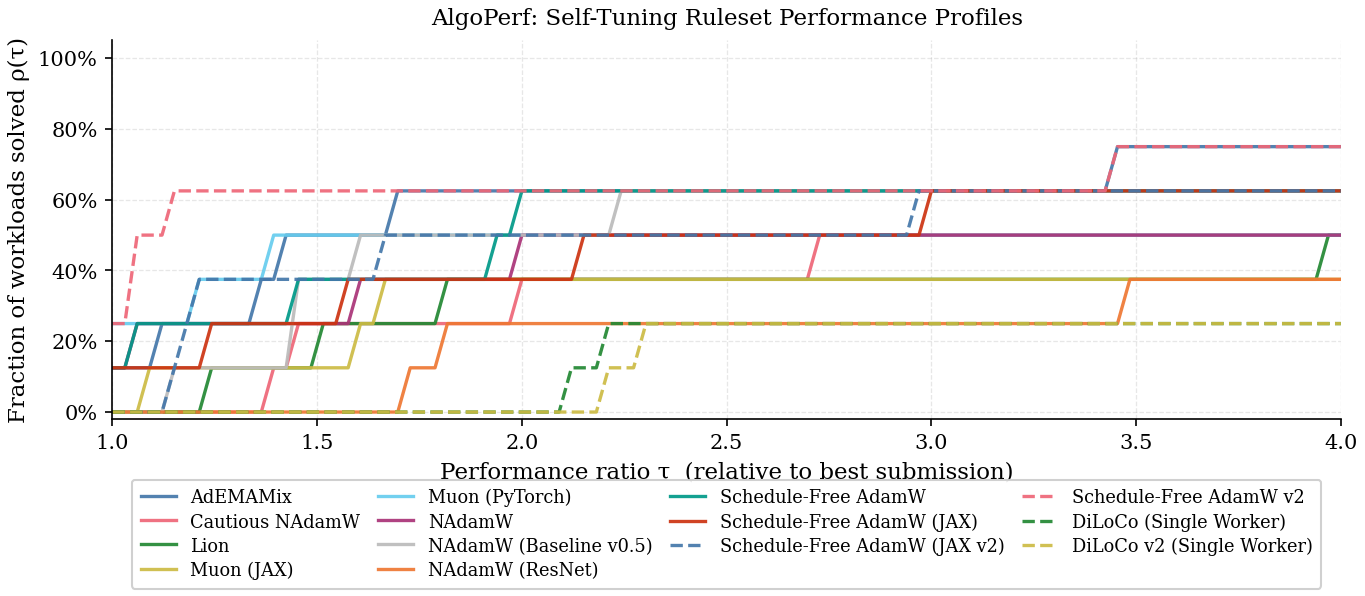

/tmp/ipykernel_2935401/3734530332.py:74: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  scores = np.trapz(df, x=df.columns)


,score
submission,
Schedule-Free AdamW v2,0.638889
AdEMAMix,0.583965
Schedule-Free AdamW,0.525253
NAdamW (Baseline v0.5),0.506944
Schedule-Free AdamW (JAX v2),0.495581
Muon (PyTorch),0.476010
Schedule-Free AdamW (JAX),0.462121
NAdamW,0.432449
Cautious NAdamW,0.353535


In [13]:
csv_file = os.path.join(OUTPUT_DIR, 'performance_profile_score.csv')

if os.path.exists(csv_file):
    reloaded_df = pd.read_csv(csv_file, index_col=0)
    reloaded_df.columns = reloaded_df.columns.astype(float)
    fig, ax = plot_performance_profiles_styled(
        reloaded_df,
        'score',
        save_dir=OUTPUT_DIR,
        title='AlgoPerf: Self-Tuning Ruleset Performance Profiles',
    )
    plt.show()
    display(compute_leaderboard_score(reloaded_df).sort_values('score', ascending=False))
else:
    print(f'No saved profile found at {csv_file}. Run Section 6 first.')